# Social-STGCNN — Baseline Verification (ADE / FDE / Collision)

Reproduces the Social-STGCNN **baseline** ADE / FDE / ColRate numbers on all five ETH-UCY scenes.

> **Baseline definition:** the original Social-STGCNN model trained with NLL loss only — **no collision penalty**.
> The collision metrics here establish the *problem* that our collision-aware extension is designed to fix.

**Before running:** Runtime → Change runtime type → **GPU (T4)**

| Step | Section | Time |
|------|---------|------|
| 1 | Environment check | ~1 min |
| 2 | Mount Drive & cd to repo | ~1 min |
| 3 | Check / train checkpoints | ~0 min if checkpoints exist; ~8 h to train all 5 |
| 4 | Evaluate ADE / FDE / ColRate | ~5 min |
| 5 | Results table | instant |
| 6 | Collision analysis & plots | instant |

## 1. Environment

In [1]:
!nvidia-smi

Mon Apr 27 12:59:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   46C    P8             13W /  220W |    1219MiB /  12282MiB |     16%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.8.0+cu126
CUDA: True
GPU: NVIDIA GeForce RTX 4070 SUPER


---
## Quick Smoke Test *(local only — skip on Colab)*

Runs **1 epoch on ETH only** to verify the full pipeline executes without errors.
Results at epoch=1 are meaningless — this is purely an executability check.

Steps covered end-to-end:
1. Train (1 epoch) → `smoke_test/social-stgcnn-eth/`
2. Evaluate the 1-epoch checkpoint (ADE / FDE / ColRate)
3. Print result table
4. Clean up the smoke-test checkpoint

> **On Colab skip this entire section** and go straight to Section 2 (Get the code).

## 2. Get the code

**Option A (Colab + Drive):** repo is already in your Google Drive at `MyDrive/DLproject-Social-STGCNN/`.  
**Option B (Colab + GitHub):** clone from GitHub (edit the URL).  
**Option C (local):** set `PROJECT_DIR` to where the repo lives on your machine.  
Run whichever option applies — skip the others.

In [3]:
# --- Option A: Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# PROJECT_DIR = '/content/drive/MyDrive/DLproject-Social-STGCNN'
# assert os.path.isdir(PROJECT_DIR), f'Repo not found at {PROJECT_DIR}'
# os.chdir(PROJECT_DIR)
# print('Working directory:', os.getcwd())

In [4]:
# --- Option B: GitHub clone (edit URL / add PAT for private repos) ---
# !git clone https://github.com/YOUR_USER/YOUR_REPO.git Social-STGCNN
# import os; os.chdir('Social-STGCNN')
# print('Working directory:', os.getcwd())

In [2]:
# --- Option C: Local machine ---
import os
PROJECT_DIR = r'D:\OMSCS\DLproject-Social-STGCNN'  # edit to your local repo path
assert os.path.isdir(PROJECT_DIR), f'Repo not found at {PROJECT_DIR}'
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())

Working directory: D:\OMSCS\DLproject-Social-STGCNN


import os, subprocess, sys, time

DATASETS     = ['eth', 'hotel', 'univ', 'zara1', 'zara2']
BASELINE_DIR = 'baseline'

# Training is sequential: one dataset at a time, ~25-40 min each on an RTX 4070 Super.
t_total_start = time.time()

for i, ds in enumerate(DATASETS, 1):
    dst = f'{BASELINE_DIR}/social-stgcnn-{ds}'
    if os.path.isfile(dst + '/val_best.pth'):
        print(f'[SKIP {i}/5] {ds} — checkpoint exists in {BASELINE_DIR}/')
        continue

    print(f'\n{"="*60}')
    print(f'[{i}/5] Training: {ds}  →  {dst}/')
    print('='*60, flush=True)

    t_start = time.time()
    proc = subprocess.Popen(
        [
            sys.executable, 'train.py',
            '--lr',         '0.01',
            '--n_stgcnn',   '1',
            '--n_txpcnn',   '5',
            '--dataset',    ds,
            '--tag',        f'social-stgcnn-{ds}',
            '--save_dir',   BASELINE_DIR,
            '--use_lrschd',
            '--num_epochs', '250',
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    elapsed = time.time() - t_start
    if proc.returncode != 0:
        print(f'\nERROR: training failed for {ds} (exit {proc.returncode})')
    else:
        print(f'\n[{i}/5] {ds} done — {elapsed/60:.1f} min  →  {dst}/')

total_elapsed = time.time() - t_total_start
print(f'\nTotal training time: {total_elapsed/3600:.2f} h')

print('\nBaseline folder contents:')
for ds in DATASETS:
    dst = f'{BASELINE_DIR}/social-stgcnn-{ds}'
    files = os.listdir(dst) if os.path.isdir(dst) else []
    status = 'OK' if 'val_best.pth' in files else 'MISSING'
    print(f'  {ds:8s}  [{status}]  {files}')

In [6]:
import os, subprocess, sys

DATASETS     = ['eth', 'hotel', 'univ', 'zara1', 'zara2']
BASELINE_DIR = 'baseline'   # custom save folder — change this to any name you like

# Train each dataset; checkpoints are written directly to BASELINE_DIR/<tag>/
for ds in DATASETS:
    dst = f'{BASELINE_DIR}/social-stgcnn-{ds}'
    if os.path.isfile(dst + '/val_best.pth'):
        print(f'[SKIP] {ds} — already in {BASELINE_DIR}/, delete to retrain')
        continue

    print(f'\n{"="*60}')
    print(f'Training baseline (NLL only): {ds}  →  {dst}/')
    print('='*60)

    result = subprocess.run([
        sys.executable, 'train.py',
        '--lr',         '0.01',
        '--n_stgcnn',   '1',
        '--n_txpcnn',   '5',
        '--dataset',    ds,
        '--tag',        f'social-stgcnn-{ds}',
        '--save_dir',   BASELINE_DIR,   # writes directly here, no copy needed
        '--use_lrschd',
        '--num_epochs', '250',
        # no --collision_loss → pure NLL baseline
    ])

    if result.returncode != 0:
        print(f'ERROR: training failed for {ds}')
    else:
        print(f'Saved → {dst}/')

print('\nBaseline folder contents:')
for ds in DATASETS:
    dst = f'{BASELINE_DIR}/social-stgcnn-{ds}'
    files = os.listdir(dst) if os.path.isdir(dst) else []
    status = 'OK' if 'val_best.pth' in files else 'MISSING'
    print(f'  {ds:8s}  [{status}]  {files}')


Training baseline (NLL only): eth  →  baseline/social-stgcnn-eth/
Saved → baseline/social-stgcnn-eth/

Training baseline (NLL only): hotel  →  baseline/social-stgcnn-hotel/
Saved → baseline/social-stgcnn-hotel/

Training baseline (NLL only): univ  →  baseline/social-stgcnn-univ/
Saved → baseline/social-stgcnn-univ/

Training baseline (NLL only): zara1  →  baseline/social-stgcnn-zara1/
Saved → baseline/social-stgcnn-zara1/

Training baseline (NLL only): zara2  →  baseline/social-stgcnn-zara2/
Saved → baseline/social-stgcnn-zara2/

Baseline folder contents:
  eth       [OK]  ['args.pkl', 'constant_metrics.pkl', 'metrics.pkl', 'val_best.pth']
  hotel     [OK]  ['args.pkl', 'constant_metrics.pkl', 'metrics.pkl', 'val_best.pth']
  univ      [OK]  ['args.pkl', 'constant_metrics.pkl', 'metrics.pkl', 'val_best.pth']
  zara1     [OK]  ['args.pkl', 'constant_metrics.pkl', 'metrics.pkl', 'val_best.pth']
  zara2     [OK]  ['args.pkl', 'constant_metrics.pkl', 'metrics.pkl', 'val_best.pth']


## 4. Evaluate — ADE / FDE / ColRate for all 5 scenes

Runs the evaluation loop with **K=20 Monte-Carlo samples** per scene.

**Trajectory accuracy metrics** (standard ETH-UCY protocol):
- **ADE** — Average Displacement Error: mean L2 distance over all peds and all 12 predicted timesteps, minimised over K samples per pedestrian.
- **FDE** — Final Displacement Error: L2 distance at the last predicted timestep only, minimised over K samples per pedestrian.

**Collision metrics** (baseline model produces no collision-aware predictions):
- **ColRate\_avg** — fraction of the K=20 sampled trajectories in which at least one pair of pedestrians comes within `d_col=0.2 m` of each other at any prediction timestep.
- **ColRate\_minADE** — whether the *best* sample (the one used for ADE/FDE reporting, i.e. the min-ADE sample) itself contains a collision.

> A high ColRate on the baseline is expected: the model was trained with **NLL loss only** and has no incentive to keep predicted trajectories collision-free.

In [7]:
import os, pickle, copy
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import torch.distributions.multivariate_normal as torchdist
from torch.utils.data import DataLoader
from tqdm.std import tqdm

from utils import TrajectoryDataset
from metrics import ade, fde, collision_metrics, seq_to_nodes, nodes_rel_to_nodes_abs
from model import social_stgcnn

DATASETS     = ['eth', 'hotel', 'univ', 'zara1', 'zara2']
BASELINE_DIR = 'baseline'
KSTEPS = 20
D_COL  = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def evaluate_checkpoint(exp_path):
    model_path = exp_path + '/val_best.pth'
    args_path  = exp_path + '/args.pkl'

    with open(args_path, 'rb') as f:
        args = pickle.load(f)

    data_set = f'./datasets/{args.dataset}/'
    dset_test = TrajectoryDataset(
        data_set + 'test/',
        obs_len=args.obs_seq_len,
        pred_len=args.pred_seq_len,
        skip=1, norm_lap_matr=True)
    loader_test = DataLoader(dset_test, batch_size=1, shuffle=False, num_workers=0)

    model = social_stgcnn(
        n_stgcnn=args.n_stgcnn, n_txpcnn=args.n_txpcnn,
        output_feat=args.output_size, seq_len=args.obs_seq_len,
        kernel_size=args.kernel_size, pred_seq_len=args.pred_seq_len
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    ade_bigls, fde_bigls = [], []
    col_avg_ls, col_minade_ls = [], []
    scene_col_avg = []

    with torch.no_grad():
        for batch in loader_test:
            batch = [t.to(device) for t in batch]
            obs_traj, pred_traj_gt, obs_traj_rel, pred_traj_gt_rel, \
                non_linear_ped, loss_mask, V_obs, A_obs, V_tr, A_tr = batch

            num_of_objs = obs_traj_rel.shape[1]

            V_pred, _ = model(V_obs.permute(0, 3, 1, 2), A_obs.squeeze())
            V_pred = V_pred.permute(0, 2, 3, 1).squeeze()
            V_tr   = V_tr.squeeze()
            V_pred, V_tr = V_pred[:, :num_of_objs, :], V_tr[:, :num_of_objs, :]

            sx   = torch.exp(V_pred[:, :, 2])
            sy   = torch.exp(V_pred[:, :, 3])
            corr = torch.tanh(V_pred[:, :, 4])
            cov  = torch.zeros(*V_pred.shape[:2], 2, 2, device=device)
            cov[:, :, 0, 0] = sx * sx
            cov[:, :, 0, 1] = corr * sx * sy
            cov[:, :, 1, 0] = corr * sx * sy
            cov[:, :, 1, 1] = sy * sy
            mvnormal = torchdist.MultivariateNormal(V_pred[:, :, 0:2], cov)

            V_x = seq_to_nodes(obs_traj.cpu().numpy().copy())
            V_x_rel_to_abs = nodes_rel_to_nodes_abs(
                V_obs.cpu().numpy().squeeze().copy(), V_x[0, :, :].copy())
            V_y_rel_to_abs = nodes_rel_to_nodes_abs(
                V_tr.cpu().numpy().squeeze().copy(), V_x[-1, :, :].copy())

            pred_samples = []
            ade_ls = {n: [] for n in range(num_of_objs)}
            fde_ls = {n: [] for n in range(num_of_objs)}

            for _ in range(KSTEPS):
                V_samp = mvnormal.sample()
                V_samp_abs = nodes_rel_to_nodes_abs(
                    V_samp.cpu().numpy().squeeze().copy(), V_x[-1, :, :].copy())
                pred_samples.append(copy.deepcopy(V_samp_abs))
                for n in range(num_of_objs):
                    ade_ls[n].append(ade([V_samp_abs[:, n:n+1, :]], [V_y_rel_to_abs[:, n:n+1, :]], [1]))
                    fde_ls[n].append(fde([V_samp_abs[:, n:n+1, :]], [V_y_rel_to_abs[:, n:n+1, :]], [1]))

            for n in range(num_of_objs):
                ade_bigls.append(min(ade_ls[n]))
                fde_bigls.append(min(fde_ls[n]))

            samples_scene = [s[:, :num_of_objs, :] for s in pred_samples]
            col_res = collision_metrics(
                samples_scene, V_y_rel_to_abs[:, :num_of_objs, :], d_col=D_COL)
            col_avg_ls.append(col_res['ColRate_avg'])
            col_minade_ls.append(col_res['ColRate_minADE'])
            scene_col_avg.append(col_res['ColRate_avg'])

    n = len(ade_bigls)
    return {
        'ade':        sum(ade_bigls) / n,
        'fde':        sum(fde_bigls) / n,
        'col_avg':    float(np.mean(col_avg_ls)),
        'col_minade': float(np.mean(col_minade_ls)),
        'pct_scenes_any_col': float(np.mean([c > 0 for c in scene_col_avg])),
    }


# --- Run evaluation ---
results = {}

for ds in tqdm(DATASETS, desc='Evaluating'):
    exp_path = f'{BASELINE_DIR}/social-stgcnn-{ds}'
    if not os.path.isfile(exp_path + '/val_best.pth'):
        print(f'  SKIP {ds} — checkpoint not found in {BASELINE_DIR}/')
        continue
    print(f'  Evaluating {ds} ...')
    results[ds] = evaluate_checkpoint(exp_path)
    r = results[ds]
    print(f'    ADE={r["ade"]:.4f}  FDE={r["fde"]:.4f}  '
          f'ColRate_avg={r["col_avg"]:.4f}  ColRate_minADE={r["col_minade"]:.4f}')

print('\nDone.')

Using device: cuda


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

  Evaluating eth ...
Processing Data .....


Evaluating:  20%|██        | 1/5 [00:02<00:11,  2.91s/it]

    ADE=0.6376  FDE=1.1157  ColRate_avg=0.0579  ColRate_minADE=0.0857
  Evaluating hotel ...
Processing Data .....


...

    ADE=0.4740  FDE=0.8574  ColRate_avg=0.8624  ColRate_minADE=0.8585
  Evaluating zara1 ...
Processing Data .....


Evaluating:  80%|████████  | 4/5 [04:12<01:10, 70.77s/it] 

    ADE=0.3474  FDE=0.5639  ColRate_avg=0.1395  ColRate_minADE=0.1329
  Evaluating zara2 ...
Processing Data .....


Evaluating: 100%|██████████| 5/5 [04:51<00:00, 58.21s/it]

    ADE=0.3045  FDE=0.4986  ColRate_avg=0.4294  ColRate_minADE=0.3941

Done.


In [8]:
# from tqdm.notebook import tqdm

# results = {}   # dataset -> metrics dict

# for ds in tqdm(DATASETS, desc='Evaluating'):
#     exp_path = f'{BASELINE_DIR}/social-stgcnn-{ds}'
#     if not os.path.isfile(exp_path + '/val_best.pth'):
#         print(f'  SKIP {ds} — checkpoint not found in {BASELINE_DIR}/')
#         continue
#     print(f'  Evaluating {ds} ...')
#     results[ds] = evaluate_checkpoint(exp_path)
#     r = results[ds]
#     print(f'    ADE={r["ade"]:.4f}  FDE={r["fde"]:.4f}  '
#           f'ColRate_avg={r["col_avg"]:.4f}  ColRate_minADE={r["col_minade"]:.4f}')

# print('\nDone.')

## 5. Results table — ADE / FDE

Compares reproduced scores against the original Social-STGCNN paper (Mohamed et al., 2020 — Table 1, K=20).

In [10]:
import pandas as pd

# Published Social-STGCNN results (Mohamed et al., 2020)
PAPER = {
    'eth':   (0.64, 1.11),
    'hotel': (0.49, 0.85),
    'univ':  (0.44, 0.79),
    'zara1': (0.34, 0.53),
    'zara2': (0.30, 0.48),
}

rows = []
for ds in DATASETS:
    if ds not in results:
        continue
    r = results[ds]
    pa, pf = PAPER.get(ds, (None, None))
    rows.append({
        'Scene':       ds,
        'ADE (ours)':  round(r['ade'], 4),
        'ADE (paper)': pa,
        'FDE (ours)':  round(r['fde'], 4),
        'FDE (paper)': pf,
    })

df_acc = pd.DataFrame(rows)

if rows:
    avg_row = {
        'Scene':       'AVG',
        'ADE (ours)':  round(df_acc['ADE (ours)'].mean(), 4),
        'ADE (paper)': round(sum(v for v, _ in PAPER.values()) / len(PAPER), 2),
        'FDE (ours)':  round(df_acc['FDE (ours)'].mean(), 4),
        'FDE (paper)': round(sum(v for _, v in PAPER.values()) / len(PAPER), 2),
    }
    df_acc = pd.concat([df_acc, pd.DataFrame([avg_row])], ignore_index=True)

print(df_acc.to_string(index=False))

Scene  ADE (ours)  ADE (paper)  FDE (ours)  FDE (paper)
  eth      0.6376         0.64      1.1157         1.11
hotel      0.4657         0.49      0.8282         0.85
 univ      0.4740         0.44      0.8574         0.79
zara1      0.3474         0.34      0.5639         0.53
zara2      0.3045         0.30      0.4986         0.48
  AVG      0.4458         0.44      0.7728         0.75


## 6. Collision analysis — baseline (no collision penalty)

The baseline is trained with **NLL loss only**. It learns the statistical distribution of
trajectories but has **no explicit incentive to keep pedestrians apart**.
The cells below quantify how often its sampled predictions contain physical collisions.

### Metric definitions

| Metric | Definition |
|--------|------------|
| **ColRate\_avg** | Fraction of K=20 sampled trajectories per scene in which any pair of pedestrians comes within `d_col` of each other at any prediction timestep. Averaged across all test scenes. Reflects how often the model proposes colliding futures. |
| **ColRate\_minADE** | Whether the *best* sample (lowest scene-ADE — the one ADE/FDE is reported on) itself contains a collision. Averaged across test scenes. The critical metric: even the model's most accurate prediction is often physically invalid. |
| **% scenes with any col.** | Fraction of test scenes where at least 1 of K=20 samples has a collision. Binary per scene — distinct from ColRate\_avg, which weights by rate within a scene. |

### Threshold note

`d_col = 0.2 m` is a conservative (strict) threshold representing direct body contact.
Some papers use `0.5 m` (personal-space boundary). Our reported rates are therefore
**lower-bound** estimates — the true collision problem is at least this bad, likely worse at 0.5 m.

In [11]:
import pandas as pd

col_rows = []
for ds in DATASETS:
    if ds not in results:
        continue
    r = results[ds]
    col_rows.append({
        'Scene':               ds,
        'ColRate_avg':         round(r['col_avg'],            4),
        'ColRate_minADE':      round(r['col_minade'],         4),
        '% scenes any col.':   f"{r['pct_scenes_any_col']*100:.1f}%",
    })

df_col = pd.DataFrame(col_rows)

if col_rows:
    avg_col = {
        'Scene':               'AVG',
        'ColRate_avg':         round(df_col['ColRate_avg'].mean(),    4),
        'ColRate_minADE':      round(df_col['ColRate_minADE'].mean(), 4),
        '% scenes any col.':   f"{df_col['% scenes any col.'].apply(lambda x: float(x.strip('%'))).mean():.1f}%",
    }
    df_col = pd.concat([df_col, pd.DataFrame([avg_col])], ignore_index=True)

print(f'Baseline collision rates  (NLL-only model, d_col={D_COL} m, K={KSTEPS})')
print()
print(df_col.to_string(index=False))
print()
print('Notes:')
print(f'  ColRate_avg     = mean fraction of {KSTEPS} samples per scene with >=1 collision')
print( '  ColRate_minADE  = fraction of scenes where the min-ADE (best) sample has a collision')
print( '  % scenes any    = fraction of scenes with ANY colliding sample (binary, not a rate)')
print(f'  d_col={D_COL} m is conservative — rates at d_col=0.5 m would be higher')

Baseline collision rates  (NLL-only model, d_col=0.2 m, K=20)

Scene  ColRate_avg  ColRate_minADE % scenes any col.
  eth       0.0579          0.0857             48.6%
hotel       0.1342          0.1163             54.8%
 univ       0.8624          0.8585             98.5%
zara1       0.1395          0.1329             57.6%
zara2       0.4294          0.3941             84.6%
  AVG       0.3247          0.3175             68.8%

Notes:
  ColRate_avg     = mean fraction of 20 samples per scene with >=1 collision
  ColRate_minADE  = fraction of scenes where the min-ADE (best) sample has a collision
  % scenes any    = fraction of scenes with ANY colliding sample (binary, not a rate)
  d_col=0.2 m is conservative — rates at d_col=0.5 m would be higher


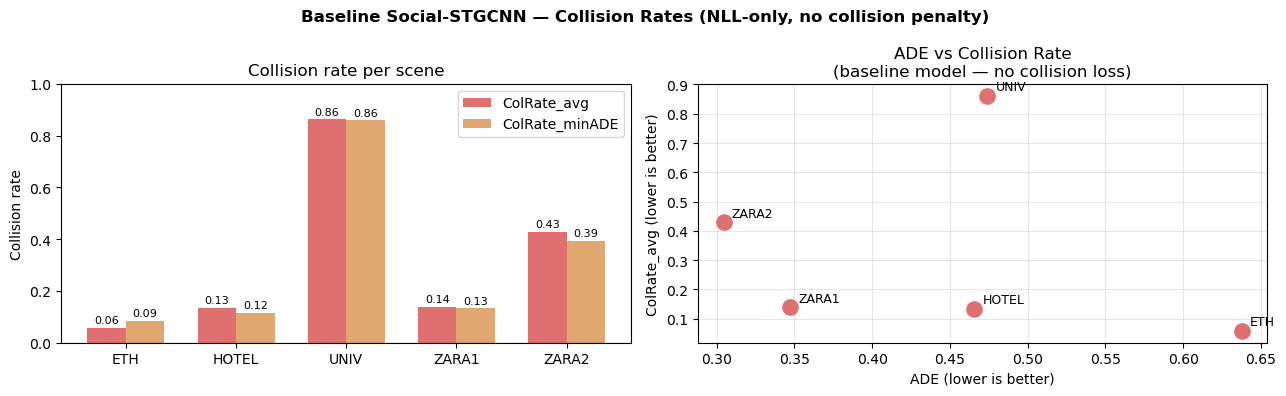

Saved: baseline_collision_analysis.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

scenes_with_data = [ds for ds in DATASETS if ds in results]
col_avg_vals   = [results[ds]['col_avg']    for ds in scenes_with_data]
col_minade_vals= [results[ds]['col_minade'] for ds in scenes_with_data]

x = np.arange(len(scenes_with_data))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Baseline Social-STGCNN — Collision Rates (NLL-only, no collision penalty)',
             fontsize=12, fontweight='bold')

# Left: grouped bar chart
ax = axes[0]
bars1 = ax.bar(x - w/2, col_avg_vals,    w, label='ColRate_avg',    color='#e07070')
bars2 = ax.bar(x + w/2, col_minade_vals, w, label='ColRate_minADE', color='#e0a870')
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in scenes_with_data])
ax.set_ylabel('Collision rate')
ax.set_ylim(0, 1.0)
ax.set_title('Collision rate per scene')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=8)

# Right: ADE vs ColRate scatter
ax2 = axes[1]
ade_vals = [results[ds]['ade'] for ds in scenes_with_data]
sc = ax2.scatter(ade_vals, col_avg_vals, c='#e07070', s=120, zorder=3)
for i, ds in enumerate(scenes_with_data):
    ax2.annotate(ds.upper(), (ade_vals[i], col_avg_vals[i]),
                 textcoords='offset points', xytext=(6, 4), fontsize=9)
ax2.set_xlabel('ADE (lower is better)')
ax2.set_ylabel('ColRate_avg (lower is better)')
ax2.set_title('ADE vs Collision Rate\n(baseline model — no collision loss)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_collision_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_collision_analysis.png')

## 7. Save results

In [14]:
import pandas as pd

all_rows = []
for ds in DATASETS:
    if ds not in results:
        continue
    r = results[ds]
    pa, pf = PAPER.get(ds, (None, None))
    all_rows.append({
        'scene':                ds,
        'ADE_ours':             round(r['ade'],               4),
        'ADE_paper':            pa,
        'FDE_ours':             round(r['fde'],               4),
        'FDE_paper':            pf,
        'ColRate_avg':          round(r['col_avg'],           4),
        'ColRate_minADE':       round(r['col_minade'],        4),
        'pct_scenes_any_col':   round(r['pct_scenes_any_col'],4),
        'collision_threshold_m': D_COL,
        'K_samples':            KSTEPS,
        'model':                'baseline_NLL_only',
    })

df_all = pd.DataFrame(all_rows)
csv_path = 'baseline_results.csv'
df_all.to_csv(csv_path, index=False)
print('Saved:', csv_path)
print(df_all.to_string(index=False))

Saved: baseline_results.csv
scene  ADE_ours  ADE_paper  FDE_ours  FDE_paper  ColRate_avg  ColRate_minADE  pct_scenes_any_col  collision_threshold_m  K_samples             model
  eth    0.6376       0.64    1.1157       1.11       0.0579          0.0857              0.4857                    0.2         20 baseline_NLL_only
hotel    0.4657       0.49    0.8282       0.85       0.1342          0.1163              0.5482                    0.2         20 baseline_NLL_only
 univ    0.4740       0.44    0.8574       0.79       0.8624          0.8585              0.9852                    0.2         20 baseline_NLL_only
zara1    0.3474       0.34    0.5639       0.53       0.1395          0.1329              0.5764                    0.2         20 baseline_NLL_only
zara2    0.3045       0.30    0.4986       0.48       0.4294          0.3941              0.8458                    0.2         20 baseline_NLL_only


In [ ]:
# Copy outputs back to Drive (only needed if repo lives in /content/, not Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# !cp baseline_results.csv         /content/drive/MyDrive/DLproject-Social-STGCNN/
# !cp baseline_collision_analysis.png /content/drive/MyDrive/DLproject-Social-STGCNN/
# print('Copied to Drive.')